In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [44]:
df = pd.read_csv('/content/social_media_addiction_dataset (1).csv')

In [45]:
df.head()

,daily_screen_time,app_opens,sleep_hours,stress_level,study_interruptions,night_usage,addiction_level
0,5.4,67,3.8,1,2,No,Moderate
1,4.3,10,6.9,2,7,No,Low
2,7.0,48,5.4,9,3,No,Moderate
3,12.0,16,6.7,2,0,No,Low
4,8.8,25,6.0,3,15,No,Moderate


In [46]:
print(df.head())
print(df.shape)
print(df.info())

   daily_screen_time  app_opens  sleep_hours  stress_level  \
0                5.4         67          3.8             1   
1                4.3         10          6.9             2   
2                7.0         48          5.4             9   
3               12.0         16          6.7             2   
4                8.8         25          6.0             3   

   study_interruptions night_usage addiction_level  
0                    2          No        Moderate  
1                    7          No             Low  
2                    3          No        Moderate  
3                    0          No             Low  
4                   15          No        Moderate  
(1000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   daily_screen_time    1000 non-null   float64
 1   app_opens            1000 non-null   in

In [47]:
print(df.isnull().sum())

daily_screen_time      0
app_opens              0
sleep_hours            0
stress_level           0
study_interruptions    0
night_usage            0
addiction_level        0
dtype: int64


In [48]:
df = df.dropna()
df.fillna(df.mean(numeric_only=True), inplace=True)

In [49]:
le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [50]:
print(df.describe())

       daily_screen_time    app_opens  sleep_hours  stress_level  \
count         1000.00000  1000.000000  1000.000000   1000.000000   
mean             6.65850    42.339000     6.035400      5.480000   
std              3.15472    21.972457     1.742511      2.927143   
min              1.00000     5.000000     3.000000      1.000000   
25%              3.90000    23.000000     4.600000      3.000000   
50%              6.70000    42.000000     5.900000      6.000000   
75%              9.40000    62.000000     7.600000      8.000000   
max             12.00000    80.000000     9.000000     10.000000   

       study_interruptions  night_usage  addiction_level  
count          1000.000000   1000.00000      1000.000000  
mean              7.831000      0.48000         1.489000  
std               4.596909      0.49985         0.802822  
min               0.000000      0.00000         0.000000  
25%               4.000000      0.00000         1.000000  
50%               8.000000      0

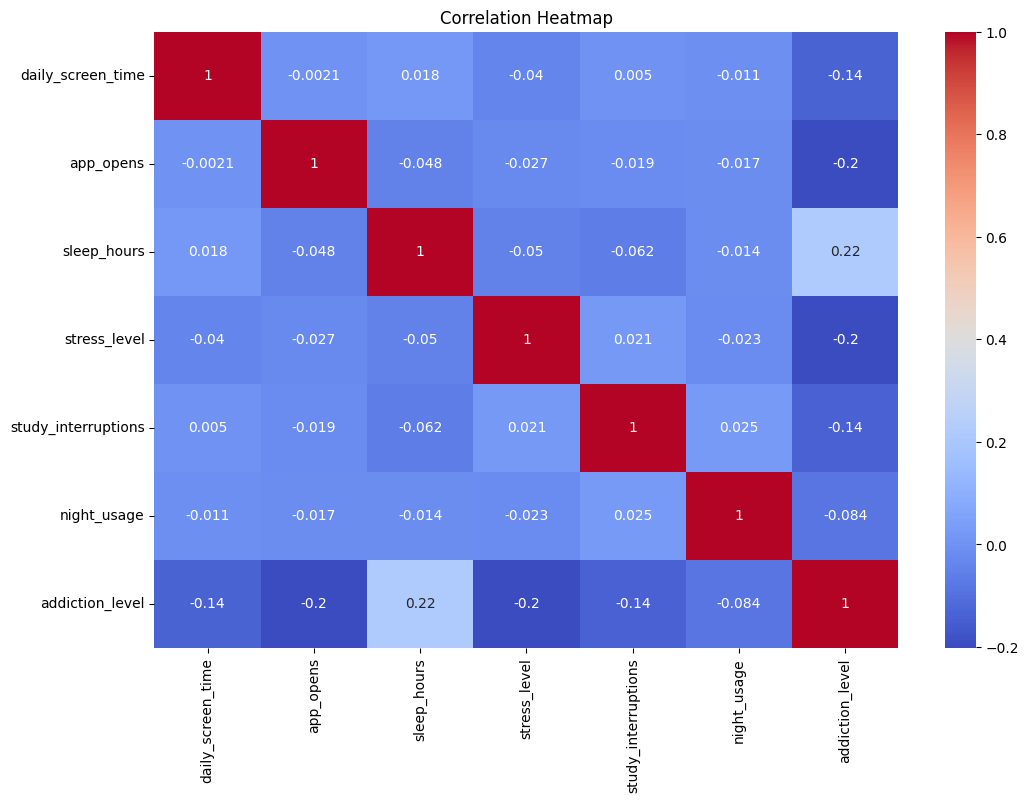

In [51]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

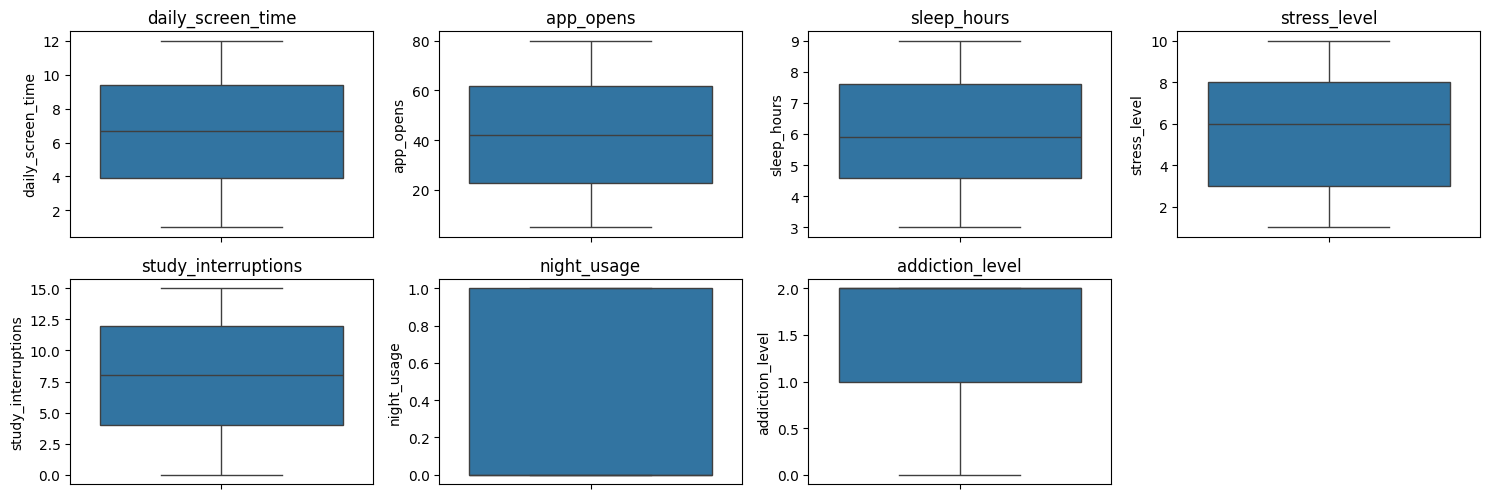

In [52]:
numerical_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [53]:
df_clean = df.copy()
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]
print("Before Removal :", df.shape)
print("After Removal :", df_clean.shape)

Before Removal : (1000, 7)
After Removal : (1000, 7)


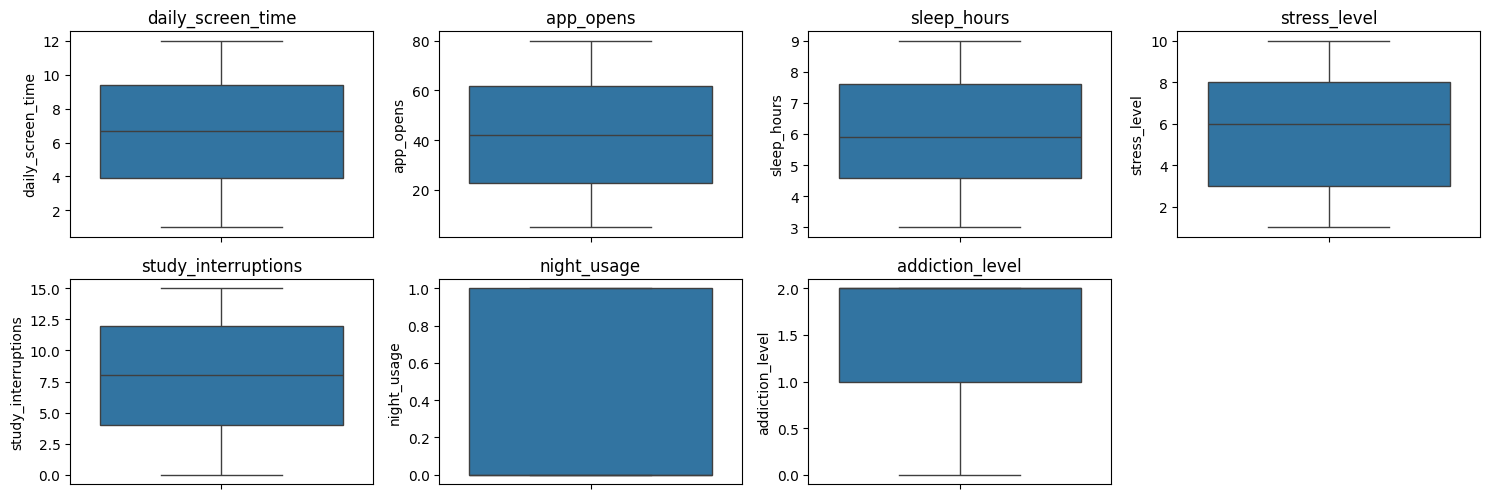

In [54]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df_clean[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [55]:
X = df.drop('addiction_level', axis=1)
y = df['addiction_level']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [57]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [58]:
y_pred = rf_model.predict(X_test)

In [59]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.885


In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.79      0.50      0.61        22
           2       0.91      0.94      0.92       149

    accuracy                           0.89       200
   macro avg       0.84      0.78      0.80       200
weighted avg       0.88      0.89      0.88       200



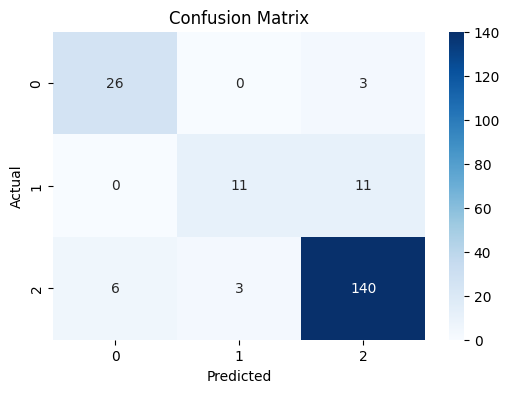

In [61]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [62]:
importance = rf_model.feature_importances_
feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})
feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_df)

               Feature  Importance
2          sleep_hours    0.216480
1            app_opens    0.213855
0    daily_screen_time    0.204252
3         stress_level    0.163882
4  study_interruptions    0.153291
5          night_usage    0.048239


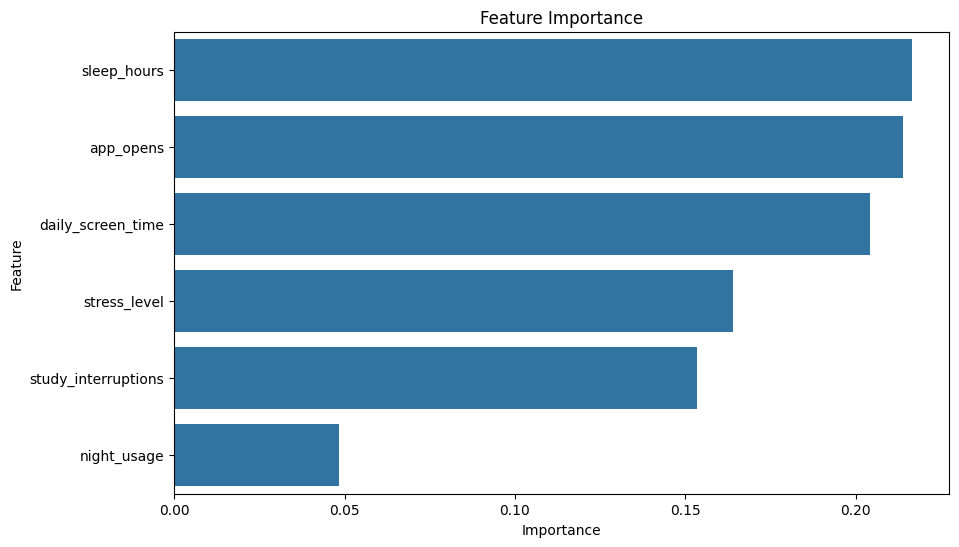

In [63]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)
plt.title("Feature Importance")
plt.show()

In [64]:
import joblib
joblib.dump(rf_model, 'social_media_addiction_model.pkl')

['social_media_addiction_model.pkl']